<a href="https://colab.research.google.com/github/williamG7/Rock-Paper-Scissors-Lizard-Spock/blob/main/Rock%2C_Paper%2C_Scissors%2C_Lizard%2C_Spock_GuzmanWilliam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Enunciado

**Objetivo**:
Dado el dataset de imágenes de Rock, Paper y Scissors de Google:
1. Siguiendo las [instrucciones del vídeo](https://youtu.be/u2TjZzNuly8), se creará y entrenará una red neuronal capaz de clasificar las imágenes en una de las 3 categorías establecidas.
2. Se añadirá un callback de parada para asegurar un accuracy >= 90%.
3. Una vez conseguido el accuracy requerido, se subirán fotos de manos en cada una de las tres categorías para comprobar si el modelo las interpreta correctamente. Las imágenes deben tener un tamaño equivalente al del dataset original (150px x 150px), por lo que será necesario editarlas previamente si es necesario.
4. Se añadirán dos categorías adicionales al modelo (junto con dos neuronas más en la última capa de salida de la red neuronal) para que también reconozca los gestos de "Lagarto" y "Spock".
5. Para entrenar el modelo con las nuevas categorías, se añadirán múltiples imágenes de cada gesto, ya sea descargadas de internet o tomadas manualmente. Cuantas más imágenes se proporcionen, mejor será el rendimiento del modelo.
6. Dentro del mismo notebook y con el modelo entrenado con un accuracy >= 80%, se implementará el juego de Piedra, Papel, Tijeras, Lagarto, Spock. El juego recibirá dos inputs de imagen (uno por jugador) y determinará el ganador. Se implementará la lógica completa del juego, permitiendo tanto la modalidad jugador1 vs jugador2 como jugador1 vs CPU (que seleccionará una figura aleatoria del 1 al 5).
7. Las reglas de la versión extendida del juego, incluyendo las dos figuras nuevas, pueden consultarse en el [vídeo adjunto](https://youtu.be/IFurn06BDuc?t=38) y en el [artículo de Wikipedia](https://ca.wikipedia.org/wiki/Pedra,_paper,_tisora,_llangardaix,_Spock?authuser=0). Cada figura gana a dos figuras y es derrotada por otras dos.


# Instalar librería keras_preprocessing

La librería keras_preprocessing no está presente dentro de Google Colab, pero la podemos instalar con **pip install**

In [ ]:
!pip install keras_preprocessing
import keras_preprocessing

# Imports

Todos los imports necesarios para el desarrollo del proyecto:

In [ ]:
import os
import shutil
import random
import glob
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf

from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
from keras.preprocessing import image as keras_image
from google.colab import files

# Importar datos

## Descargar datos

Importaremos los datos de la API de Google:

In [ ]:
!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/rps.zip \
    -O /tmp/rps.zip

!wget --no-check-certificate \
    https://storage.googleapis.com/learning-datasets/rps-test-set.zip \
    -O /tmp/rps-test-set.zip

--2026-02-15 17:47:23--  https://storage.googleapis.com/learning-datasets/rps.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.203.207, 74.125.204.207, 64.233.187.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.203.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 200682221 (191M) [application/zip]
Saving to: ‘/tmp/rps.zip’

/tmp/rps.zip        100%[===================>] 191.38M  29.6MB/s    in 7.4s    

2026-02-15 17:47:31 (25.9 MB/s) - ‘/tmp/rps.zip’ saved [200682221/200682221]

--2026-02-15 17:47:31--  https://storage.googleapis.com/learning-datasets/rps-test-set.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.203.207, 74.125.204.207, 64.233.187.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.203.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29516758 (28M) [application/zip]
Saving to: ‘/tmp/rps-test-set.zip’

/tmp/rps-

## Descomprimir datos

Guardaremos las imágenes en un directorio temporal.
Podéis adaptar el código para que os lo guarde en GDrive.

In [ ]:
local_zip = '/tmp/rps.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/')
zip_ref.close()

local_zip = '/tmp/rps-test-set.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/')
zip_ref.close()

## Comprobar recuento de imágenes

Un poco de EDA sobre las carpetas generadas:

In [ ]:
# Definimos directorios con ruta relativa hacia cada una de las carpetas de imágenes
rock_dir = os.path.join('/tmp/rps/rock')
paper_dir = os.path.join('/tmp/rps/paper')
scissors_dir = os.path.join('/tmp/rps/scissors')

# Imprimir recuentos
print('total training rock images:', len(os.listdir(rock_dir)))
print('total training paper images:', len(os.listdir(paper_dir)))
print('total training scissors images:', len(os.listdir(scissors_dir)))

# Imprimir el nombre de los últimos 10 archivos de imágenes de cada carpeta para ver la convención de nombres
rock_files = os.listdir(rock_dir)
print(rock_files[:10])

paper_files = os.listdir(paper_dir)
print(paper_files[:10])

scissors_files = os.listdir(scissors_dir)
print(scissors_files[:10])

total training rock images: 840
total training paper images: 840
total training scissors images: 840
['rock06ck02-023.png', 'rock04-106.png', 'rock04-035.png', 'rock02-038.png', 'rock05ck01-041.png', 'rock05ck01-109.png', 'rock03-013.png', 'rock02-063.png', 'rock03-055.png', 'rock07-k03-107.png']
['paper02-056.png', 'paper05-078.png', 'paper06-056.png', 'paper05-108.png', 'paper06-098.png', 'paper04-105.png', 'paper06-040.png', 'paper06-112.png', 'paper06-093.png', 'paper06-022.png']
['scissors01-040.png', 'testscissors02-013.png', 'scissors04-031.png', 'scissors03-075.png', 'scissors02-109.png', 'scissors03-056.png', 'scissors02-054.png', 'scissors04-114.png', 'testscissors02-021.png', 'testscissors01-001.png']


## Carpetas temporales donde guarda las imágenes

A continuación podemos ver la estructura de carpetas que crea para guardar las imágenes descargadas. Crea una carpeta por cada categoría.

También es interesante observar cómo nombra las imágenes, por ejemplo: `scissors01-000.png`

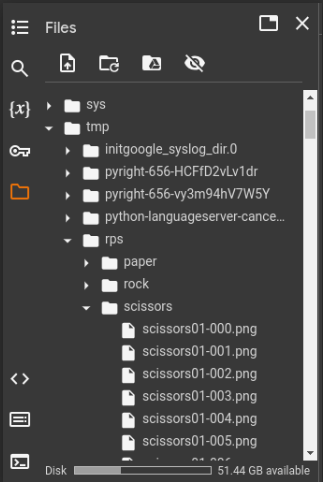

## Visualización de imágenes

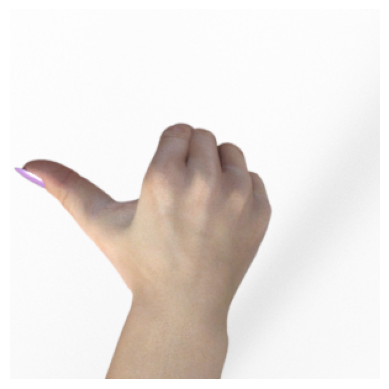

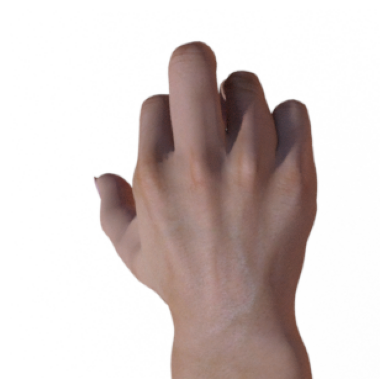

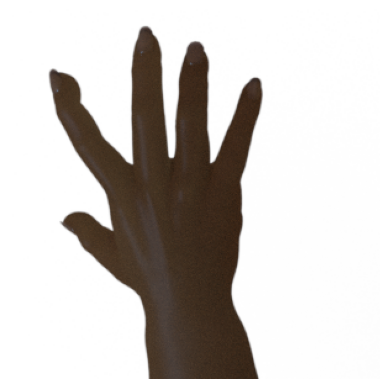

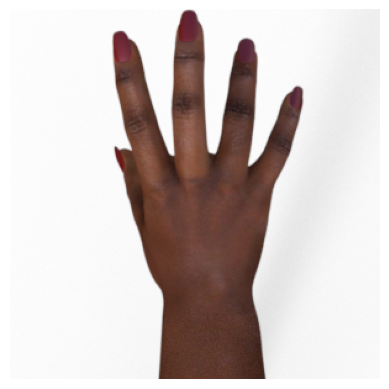

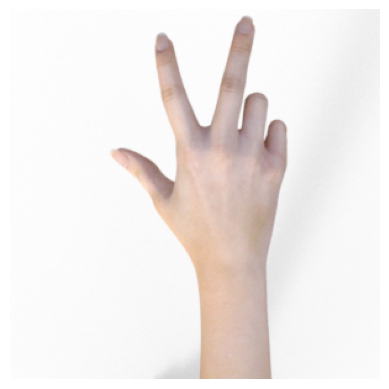

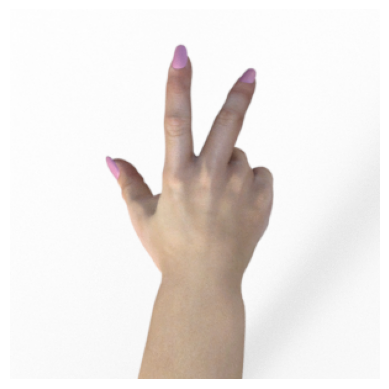

In [ ]:
%matplotlib inline

pic_index = 2

next_rock = [os.path.join(rock_dir, fname)
                for fname in rock_files[pic_index-2:pic_index]]
next_paper = [os.path.join(paper_dir, fname)
                for fname in paper_files[pic_index-2:pic_index]]
next_scissors = [os.path.join(scissors_dir, fname)
                for fname in scissors_files[pic_index-2:pic_index]]

for i, img_path in enumerate(next_rock+next_paper+next_scissors):
  #print(img_path)
  img = mpimg.imread(img_path)
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

# Preparar dataset train-test

Dividimos el dataset en 80-20:

In [ ]:
TRAINING_DIR = "/tmp/rps/"
training_datagen = ImageDataGenerator(
      rescale = 1./255,
	    rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

VALIDATION_DIR = "/tmp/rps-test-set/"
validation_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = training_datagen.flow_from_directory(
	TRAINING_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126,
  classes=['rock', 'paper', 'scissors']
)

validation_generator = validation_datagen.flow_from_directory(
	VALIDATION_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126,
  classes=['rock', 'paper', 'scissors']
)

Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.


# Red neuronal

## Definir red neuronal

- Definimos una red neuronal con un input de imágenes de 150px-150px y con 3 categorías posibles: `input_shape=(150, 150, 3)`
- Aplicamos pre-procesamiento de las imágenes de input con `Conv2D` y `MaxPooling2D`.
- Aplanamos las matrices a vectores 1D: `tf.keras.layers.Flatten()`
- Definimos capa intermedia de 512 neuronas: `tf.keras.layers.Dense(512, activation='relu')`
- Definimos capa de salida con 3 neuronas de salida posibles (Piedra, Papel o Tijeras): `tf.keras.layers.Dense(3, activation='softmax')`

In [ ]:
# Definir modelo
model = tf.keras.models.Sequential([
    # Nótese que el input shape es el tamaño deseado de la imagen 150x150 con 3 bytes de color
    # Esta es la primera convolución
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    # La segunda convolución
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # La tercera convolución
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # La cuarta convolución
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # Flatten los resultados para alimentar a una DNN
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    # Capa oculta de 512 neuronas
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

# Visualizar detalle del modelo
model.summary()

# Configurar modo de compilación de la red y optimizador
model.compile(loss = 'categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,473,475 (13.25 MB)

 Trainable params: 3,473,475 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

## Añadir call back al modelo entrenado

Modificar la red neuronal dada para Rock, Paper, Scissors y añadirle un callback que asegure un >=90% de accuracy.

In [ ]:
class PararEnAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, objetivo=0.90, monitor="val_accuracy"):
        super().__init__()
        self.objetivo = objetivo
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        valor = logs.get(self.monitor)
        if valor is not None and valor >= self.objetivo:
            print(f"\n{self.monitor} = {valor:.3f} (>= {self.objetivo}). Entrenamiento parado.")
            self.model.stop_training = True

callback_90 = PararEnAccuracy(objetivo=0.90, monitor="val_accuracy")

early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

## Entrenar modelo

Una vez tenemos el callback definido, podemos entrenar el modelo con el siguiente código AÑADIENDO EL CALLBACK:

In [ ]:
history = model.fit(
    train_generator,
    epochs=25,
    steps_per_epoch=20,
    validation_data=validation_generator,
    verbose=1,
    validation_steps=3,
    callbacks=[callback_90, early]  # Callback
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 236s 12s/step - accuracy: 0.5009 - loss: 0.9463 - val_accuracy: 0.6667 - val_loss: 0.5722
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 219s 11s/step - accuracy: 0.5463 - loss: 0.9225 - val_accuracy: 0.7876 - val_loss: 0.5063
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.6706 - loss: 0.7501 
val_accuracy = 0.957 (>= 0.9). Entrenamiento parado.
20/20 ━━━━━━━━━━━━━━━━━━━━ 287s 12s/step - accuracy: 0.6712 - loss: 0.7487 - val_accuracy: 0.9570 - val_loss: 0.2529


Cuando el modelo supera el 90% de val_accuracy, el callback detiene el entrenamiento automáticamente para no entrenar más de lo necesario.

## Guardamos el modelo entrenado

Podemos guardar la configuración y entrenamiento del modelo:

In [ ]:
#model.save("rps.h5")
model.save("my_model.keras")

## Comprobar modelo entrenado

Podemos comprobar el accuracy tanto del grupo de training como del grupo de validación:

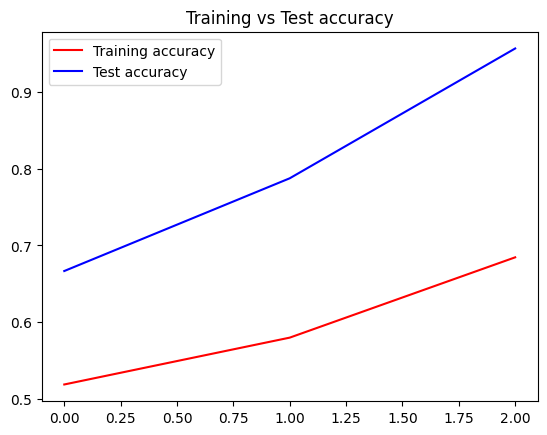

<Figure size 640x480 with 0 Axes>

In [ ]:
acc = history.history['accuracy']
test_acc = history.history['val_accuracy']

# loss = history.history['loss']
# test_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, test_acc, 'b', label='Test accuracy')
plt.title('Training vs Test accuracy')
plt.legend(loc=0)
plt.figure()

plt.show()

# Probar modelo con vuestras propias imágenes

El siguiente código permitirá subir imágenes vuestras desde el Collab como input para el modelo.

Las imágenes que subáis deben ser de 150px*150px

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargar imágenes desde el Collab
uploaded = files.upload()

for fn in uploaded.keys():

  # prediciendo imágenes
  path = fn
  img = image.load_img(path, target_size=(150, 150))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = x / 255.0


  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)
  print(fn)
  print(classes)
  print(train_generator.class_indices)

Saving IMG_2548.PNG to IMG_2548.PNG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
IMG_2548.PNG
[[0.6751551  0.14100799 0.1838368 ]]
{'rock': 0, 'paper': 1, 'scissors': 2}


# Incorporar las neuronas de Lagarto y Spock

Añadid dos categorías más a vuestro modelo de red neuronal para que pueda reconocer Lagarto y Spock.

Tabla de puntuaciones de Player 1 (filas) vs Player 2 (columnas) y las puntuaciones que obtienen cada uno de ellos en cada caso:
![Tabla de puntuaciones RPSLS](https://upload.wikimedia.org/wikipedia/commons/1/17/Normal_form_matrix_of_Rock-paper-scissors-lizard-Spock.jpg)

Por ejemplo, si Player 1 fila 3 y Player 2 columna 2 (Tijeras vs Papel), gana Player 1; por eso puntuación `1, -1` dentro de la casilla.

Será necesario crear y procesar imágenes de las dos nuevas categorías y redefinir el modelo y reentrenarlo.

In [ ]:
# Rutas
DRIVE_DIR  = "/content/drive/MyDrive/imagenes-manos"
ORIG_TRAIN = "/tmp/rps" # Dataset original
ORIG_VAL   = "/tmp/rps-test-set"

NEW_TRAIN  = "/tmp/rps5/train" # Nuevo dataset con 5 clases
NEW_VAL    = "/tmp/rps5/val"

CLASES_ORIG = ["rock", "paper", "scissors"]
CLASES_NEW  = ["lizard", "spock"]

# Crear estructura de carpetas
for cls in CLASES_ORIG + CLASES_NEW:
    os.makedirs(os.path.join(NEW_TRAIN, cls), exist_ok=True)
    os.makedirs(os.path.join(NEW_VAL,   cls), exist_ok=True)

# Copiar rock/paper/scissors del dataset original
for cls in CLASES_ORIG:
    for img in glob.glob(os.path.join(ORIG_TRAIN, cls, "*")):
        shutil.copy(img, os.path.join(NEW_TRAIN, cls))
    for img in glob.glob(os.path.join(ORIG_VAL, cls, "*")):
        shutil.copy(img, os.path.join(NEW_VAL, cls))

# Copiar lizard/spock desde Drive y hacer split 80/20
def copiar_split(origen_drive, dest_train, dest_val, val_ratio=0.2):
    imgs = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.webp"):
        imgs += glob.glob(os.path.join(origen_drive, ext))
    random.shuffle(imgs)
    cut = int(len(imgs) * (1 - val_ratio))
    for p in imgs[:cut]:
        shutil.copy(p, os.path.join(dest_train, os.path.basename(p)))
    for p in imgs[cut:]:
        shutil.copy(p, os.path.join(dest_val, os.path.basename(p)))
    return len(imgs[:cut]), len(imgs[cut:])

lz_tr, lz_val = copiar_split(
    os.path.join(DRIVE_DIR, "lagartija"),
    os.path.join(NEW_TRAIN, "lizard"),
    os.path.join(NEW_VAL,   "lizard"),
)
sp_tr, sp_val = copiar_split(
    os.path.join(DRIVE_DIR, "spock"),
    os.path.join(NEW_TRAIN, "spock"),
    os.path.join(NEW_VAL,   "spock"),
)

print(f"lizard  -> train: {lz_tr}  val: {lz_val}")
print(f"spock   -> train: {sp_tr}  val: {sp_val}")
print("Clases TRAIN:", sorted(os.listdir(NEW_TRAIN)))
print("Clases VAL:  ", sorted(os.listdir(NEW_VAL)))"

lizard  -> train: 176  val: 44
spock   -> train: 128  val: 33
Clases TRAIN: ['lizard', 'paper', 'rock', 'scissors', 'spock']
Clases VAL:   ['lizard', 'paper', 'rock', 'scissors', 'spock']


# Redefinir y entrenar el modelo con 5 clases

### Generadores

In [ ]:
train_datagen5 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen5 = ImageDataGenerator(rescale=1./255)

train_generator5 = train_datagen5.flow_from_directory(
    NEW_TRAIN,
    target_size=(150, 150),
    class_mode='categorical',
    batch_size=64,
    classes=['rock', 'paper', 'scissors', 'lizard', 'spock']
)
val_generator5 = val_datagen5.flow_from_directory(
    NEW_VAL,
    target_size=(150, 150),
    class_mode='categorical',
    batch_size=64,
    classes=['rock', 'paper', 'scissors', 'lizard', 'spock']
)

print("Índice de clases:", train_generator5.class_indices)

Found 2824 images belonging to 5 classes.
Found 449 images belonging to 5 classes.
Índice de clases: {'rock': 0, 'paper': 1, 'scissors': 2, 'lizard': 3, 'spock': 4}


### Modelo con 5 clases

In [ ]:
model5 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax') # 5 clases
])

model5.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

### Añadimos Callback >=80%

In [ ]:
callback_80 = PararEnAccuracy(objetivo=0.80, monitor="val_accuracy")
early5 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history5 = model5.fit(
    train_generator5,
    epochs=30,
    validation_data=val_generator5,
    verbose=1,
    callbacks=[callback_80, early5]
)

model5.save("rps5.keras")

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 271s 6s/step - accuracy: 0.3042 - loss: 2.0247 - val_accuracy: 0.2762 - val_loss: 1.4974
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 289s 6s/step - accuracy: 0.4122 - loss: 1.3009 - val_accuracy: 0.4699 - val_loss: 1.0978
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 268s 6s/step - accuracy: 0.5106 - loss: 1.1075 - val_accuracy: 0.5902 - val_loss: 0.8898
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 285s 6s/step - accuracy: 0.6070 - loss: 0.8693 - val_accuracy: 0.6882 - val_loss: 0.8791
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 275s 6s/step - accuracy: 0.7384 - loss: 0.6762 - val_accuracy: 0.7706 - val_loss: 0.5599
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7992 - loss: 0.5466
val_accuracy = 0.862 (>= 0.8). Entrenamiento parado.
45/45 ━━━━━━━━━━━━━━━━━━━━ 279s 6s/step - accuracy: 0.7997 - loss: 0.5454 - val_accuracy: 0.8619 - val_loss: 0.3773


# Implementar el juego Rock, Paper, Scissors, Lizard, Spock

El juego debe permitir:
1. **Player 1 vs Player 2**: pedir una imagen de la mano de cada player con su opción.
2. **Player 1 vs CPU**: pedir la imagen de la mano del player 1

En los dos casos, debe mostrar quién gana.

In [ ]:
# Implementación del juego: Rock, Paper, Scissors, Lizard, Spock
# Mapeo indice
idx_to_class = {v: k for k, v in train_generator5.class_indices.items()}
print("Clases del modelo (5 clases):", sorted(train_generator5.class_indices.keys()))

# Reglas
REGLAS = {
    "rock":     ["scissors", "lizard"],
    "paper":    ["rock",     "spock"],
    "scissors": ["paper",    "lizard"],
    "lizard":   ["spock",    "paper"],
    "spock":    ["scissors", "rock"],
}

TODAS_LAS_CLASES = list(REGLAS.keys())  # Las 5 opciones posibles para la CPU

# Funciones auxiliares
def determinar_ganador(jugada_j1, jugada_j2):
    """
    Determina el ganador comparando las dos jugadas.
    Devuelve: "jugador1", "jugador2" o "empate"
    """
    if jugada_j1 == jugada_j2:
        return "empate"
    elif jugada_j2 in REGLAS[jugada_j1]:
        # j1 gana a j2
        return "jugador1"
    else:
        # j2 gana a j1
        return "jugador2"


def predecir_clase_desde_imagen():
    """
    Pide al usuario que suba una imagen, la procesa con el modelo de 5 clases
    y devuelve el nombre de la clase predicha (rock, paper, scissors, lizard o spock).
    """
    uploaded = files.upload()
    nombre_archivo = list(uploaded.keys())[0]

    # Cargar y preprocesar la imagen (mismo formato que en el entrenamiento)
    img = keras_image.load_img(nombre_archivo, target_size=(150, 150))
    x   = keras_image.img_to_array(img)
    x   = np.expand_dims(x, axis=0)
    x   = x / 255.0

    # Prediccion del modelo
    probabilidades = model5.predict(x, verbose=0)[0]
    indice         = int(np.argmax(probabilidades))
    clase          = idx_to_class[indice]
    confianza      = float(probabilidades[indice])

    print(f"  Archivo: {nombre_archivo}")
    print(f"  Predicción: {clase.upper()} (confianza: {confianza:.2%})")
    return clase


def mostrar_resultado(jugada_j1, jugada_j2, nombre_j2="Jugador 2"):
    """
    Imprime las jugadas y el resultado final de la ronda.
    """
    ganador = determinar_ganador(jugada_j1, jugada_j2)

    print()
    print("=" * 45)
    print(f"  Jugador 1  :  {jugada_j1.upper()}")
    print(f"  {nombre_j2:<11}:  {jugada_j2.upper()}")
    print("-" * 45)

    if ganador == "empate":
        print("RESULTADO: EMPATE")
    elif ganador == "jugador1":
        print("RESULTADO: GANA JUGADOR 1")
    else:
        print(f"RESULTADO: GANA {nombre_j2.upper()}")

    print("=" * 45)

# Menú principal
print()
print("=========================================")
print("ROCK - PAPER - SCISSORS - LIZARD - SPOCK")
print("=========================================")
print("  1) Jugador 1 vs Jugador 2")
print("  2) Jugador 1 vs CPU (aleatorio)")
print("-----------------------------------------")

modo = input("Elige modo (1 o 2): ").strip()

if modo == "1":
    jugar_jugador_vs_jugador()
elif modo == "2":
    jugar_jugador_vs_cpu()
else:
    print("Opción no válida. Ejecuta de nuevo y elige 1 o 2.")"

Clases del modelo (5 clases): ['lizard', 'paper', 'rock', 'scissors', 'spock']

ROCK - PAPER - SCISSORS - LIZARD - SPOCK
  1) Jugador 1 vs Jugador 2
  2) Jugador 1 vs CPU (aleatorio)
-----------------------------------------
Elige modo (1 o 2): 1

--- JUGADOR 1: sube tu imagen ---


Saving spock02-005.png to spock02-005.png
  Archivo: spock02-005.png
  Prediccion: SPOCK (confianza: 68.03%)

--- JUGADOR 2: sube tu imagen ---


Saving IMG_3240 Small.png to IMG_3240 Small.png
  Archivo: IMG_3240 Small.png
  Prediccion: LIZARD (confianza: 66.36%)

  Jugador 1  :  SPOCK
  Jugador 2  :  LIZARD
---------------------------------------------
RESULTADO: GANA JUGADOR 2


# Annex

> Instalar librerías extra en Google Colab: https://colab.research.google.com/notebooks/snippets/importing_libraries.ipynb#scrollTo=PeaSX9KXR58J

# Conclusión

En este proyecto se ha creado y entrenado una red neuronal capaz de clasificar las cinco clases del juego (Rock, Paper, Scissors, Lizard, Spock). Inicialmente se trabajó con las 3 clases originales implementando un callback con un umbral de val_accuracy del 90%, para posteriormente integrar las clases Spock y Lizard alimentadas con imágenes importadas a través de Google Drive. El proceso que mayor tiempo requirió fue la recopilación e introducción de imágenes, ya que para un correcto aprendizaje del modelo fue necesario proporcionar una cantidad considerable de muestras para cada una de las dos nuevas clases.